In [1]:
import pandas as pd
import numpy as np
file_path = r'C:\Users\My Name Devon\OneDrive\Documents\WGU MSDA\D208\medical_clean.csv'
df = pd.read_csv(file_path, index_col = 0)
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_id         10000 non-null  object 
 1   Interaction         10000 non-null  object 
 2   UID                 10000 non-null  object 
 3   City                10000 non-null  object 
 4   State               10000 non-null  object 
 5   County              10000 non-null  object 
 6   Zip                 10000 non-null  int64  
 7   Lat                 10000 non-null  float64
 8   Lng                 10000 non-null  float64
 9   Population          10000 non-null  int64  
 10  Area                10000 non-null  object 
 11  TimeZone            10000 non-null  object 
 12  Job                 10000 non-null  object 
 13  Children            10000 non-null  int64  
 14  Age                 10000 non-null  int64  
 15  Income              10000 non-null  float64
 16  Marital  

In [2]:
#Looking for duplicates in the dataset
df.duplicated().sum()

0

In [3]:
print(df['State'].unique())
df.State.value_counts().count()

['AL' 'FL' 'SD' 'MN' 'VA' 'OK' 'OH' 'MS' 'WI' 'IA' 'CA' 'IN' 'MO' 'MI'
 'NE' 'PA' 'AR' 'WV' 'KS' 'MA' 'KY' 'NY' 'VT' 'DC' 'IL' 'ND' 'SC' 'AK'
 'NM' 'NH' 'GA' 'NC' 'MD' 'TN' 'WA' 'TX' 'CO' 'NJ' 'LA' 'OR' 'AZ' 'ME'
 'ID' 'UT' 'RI' 'MT' 'PR' 'NV' 'CT' 'HI' 'WY' 'DE']


52

In [5]:
#Investigating outliers in the VitD_levels variable
import sklearn

# IQR
# Calculate the upper and lower limits
Q1 = df['VitD_levels'].quantile(0.25)
Q3 = df['VitD_levels'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(IQR)

# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df['VitD_levels'] >= upper)[0]
print(len(upper_array))
lower_array = np.where(df['VitD_levels'] <= lower)[0]
print(len(lower_array))

2.721523887500002
33
27


In [6]:
# Looking for highest and lowest 20 values in VitD_levels
print(df.VitD_levels.nlargest(n=20))
print(df.VitD_levels.nsmallest(n=20))

CaseOrder
4370    26.394449
4186    25.444099
6830    25.147270
8252    24.889110
7910    24.637420
23      24.565463
508     24.559132
8851    24.538710
8349    24.450370
4530    24.421656
2383    24.371580
6948    24.356250
8409    24.166720
8844    24.098840
1664    23.941426
3564    23.938421
468     23.906407
2705    23.852194
7158    23.833530
8576    23.739160
Name: VitD_levels, dtype: float64
CaseOrder
8141     9.806483
3289    10.315234
1316    10.877427
5259    11.083430
636     11.475314
5066    11.538730
9271    11.751060
8492    11.755560
510     11.785395
7188    11.846830
6793    11.966340
9510    12.038470
4382    12.062467
1629    12.072534
4260    12.074147
1440    12.091658
8198    12.118830
3503    12.207388
7226    12.219040
813     12.313590
Name: VitD_levels, dtype: float64


In [7]:
#Investigating outliers in the TotalCharge variable
import sklearn

# IQR
# Calculate the upper and lower limits
Q1 = df['TotalCharge'].quantile(0.25)
Q3 = df['TotalCharge'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(IQR)

# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df['TotalCharge'] >= upper)[0]
print(len(upper_array))
lower_array = np.where(df['TotalCharge'] <= lower)[0]
print(len(lower_array))

4280.325734999999
0
0


In [8]:
new_columns = ["customer_id", "interaction", "uid", "city", "state", "county", 
                    "zip", "latitude", "longitude", "population", "area", "timezone", "job", "children_in_household", 
                    "age", "sponsor_income", "marital_status", "gender", "readmis_within_month", 
                    "vitd_lvl", "pcm_visits", "hosp_meals_eaten", "vitd_supp", "soft_drink_consumption", "initial_admin", 
                    "high_blood_pressure", "stroke", "complication_risk", "overweight", "arthritis", "diabetes", "hyperlipidemia", 
                    "back_pain", "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma", "services", 
                    "initial_stay", "est_daily_charge", "est_additional_charges", "likert_timely_admission", "likert_timely_treatment", 
                    "likert_timely_visit", "likert_reliablity", "likert_options", "likert_treatment_hrs", "likert_courteous_staff", 
                    "likert_dr_active_listening"]
df.columns = new_columns
print(df.columns)

Index(['customer_id', 'interaction', 'uid', 'city', 'state', 'county', 'zip',
       'latitude', 'longitude', 'population', 'area', 'timezone', 'job',
       'children_in_household', 'age', 'sponsor_income', 'marital_status',
       'gender', 'readmis_within_month', 'vitd_lvl', 'pcm_visits',
       'hosp_meals_eaten', 'vitd_supp', 'soft_drink_consumption',
       'initial_admin', 'high_blood_pressure', 'stroke', 'complication_risk',
       'overweight', 'arthritis', 'diabetes', 'hyperlipidemia', 'back_pain',
       'anxiety', 'allergic_rhinitis', 'reflux_esophagitis', 'asthma',
       'services', 'initial_stay', 'est_daily_charge',
       'est_additional_charges', 'likert_timely_admission',
       'likert_timely_treatment', 'likert_timely_visit', 'likert_reliablity',
       'likert_options', 'likert_treatment_hrs', 'likert_courteous_staff',
       'likert_dr_active_listening'],
      dtype='object')


In [9]:
#state
df["state"] = df["state"].astype("category")

#zip
df['zip'] = df['zip'].astype("str").str.zfill(5)

#area
df["area"] = df["area"].astype("category")

#timezone
df["timezone"] = df["timezone"].astype("category")

#children_in_household
df["children_in_household"] = df["children_in_household"].astype("Int64")

#sponsor_income
df["sponsor_income"] = df["sponsor_income"].round(2)

#marital_status
df["marital_status"] = df["marital_status"].astype("category")

#gender
df["gender"] = df["gender"].astype("category")

#soft_drink_consumption
df["soft_drink_consumption"] = df["soft_drink_consumption"].astype("bool")

#initial_admin
df["initial_admin"] = df["initial_admin"].astype("category")

#complication_risk
df["complication_risk"] = df["complication_risk"].astype("category")

#services
df["services"] = df["services"].astype("category")

#initial_stay
df["initial_stay"] = df.initial_stay.round(2)
df["initial_stay"] = df["initial_stay"].astype("int64")

#est_daily_charge
df["est_daily_charge"] = df.est_daily_charge.round(2)
df["est_daily_charge"] = df["est_daily_charge"].astype("int64")

#est_additional_charges
df["est_additional_charges"] = df.est_additional_charges.round(2)
df["est_additional_charges"] = df["est_additional_charges"].astype("int64")

#likert_timely_admission
df["likert_timely_admission"] = df["likert_timely_admission"].astype("category")

#likert_timely_treatment
df["likert_timely_treatment"] = df["likert_timely_treatment"].astype("category")

#likert_timely_visit
df["likert_timely_visit"] = df["likert_timely_visit"].astype("category")

#likert_reliablity
df["likert_reliablity"] = df["likert_reliablity"].astype("category")

#likert_options
df["likert_options"] = df["likert_options"].astype("category")

#likert_treatment_hrs
df["likert_treatment_hrs"] = df["likert_treatment_hrs"].astype("category")

#likert_courteous_staff
df["likert_courteous_staff"] = df["likert_courteous_staff"].astype("category")

#likert_dr_active_listening
df["likert_dr_active_listening"] = df["likert_dr_active_listening"].astype("category")

# Save dataset to CSV, ignore index (if included, this will create an additional unnecessary column)
df.to_csv('cleanedv2.csv', index=False)
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   customer_id                 10000 non-null  object  
 1   interaction                 10000 non-null  object  
 2   uid                         10000 non-null  object  
 3   city                        10000 non-null  object  
 4   state                       10000 non-null  category
 5   county                      10000 non-null  object  
 6   zip                         10000 non-null  object  
 7   latitude                    10000 non-null  float64 
 8   longitude                   10000 non-null  float64 
 9   population                  10000 non-null  int64   
 10  area                        10000 non-null  category
 11  timezone                    10000 non-null  category
 12  job                         10000 non-null  object  
 13  children_in_household

In [10]:
#Code showing summary statistics the high blood pressure variable and conducting t-test of independence exploring the potential relationship between patients with high blood pressure (categorical variable) and patient readmission (categorical variable)
print(df.readmis_within_month.describe())

count     10000
unique        2
top          No
freq       6331
Name: readmis_within_month, dtype: object


In [11]:
#Code showing summary statistics for the vitamin d level variable and conducting t-test of independence exploring the potential relationship between patient vitamin D levels (continuous variable) and patient readmission (categorical variable)
import pandas as pd
import scipy.stats as stats

print(df.vitd_lvl.describe())

stats.ttest_ind(df['vitd_lvl'][df['readmis_within_month'] == 'Yes'],
                df['vitd_lvl'][df['readmis_within_month'] == 'No'])

count    10000.000000
mean        17.964262
std          2.017231
min          9.806483
25%         16.626439
50%         17.951122
75%         19.347963
max         26.394449
Name: vitd_lvl, dtype: float64


TtestResult(statistic=0.40822135318600616, pvalue=0.683119914739662, df=9998.0)

In [14]:
#Code showing summary statistics the high blood pressure variable and conducting t-test of independence exploring the potential relationship between patients with high blood pressure (categorical variable) and patient readmission (categorical variable)
print(df.high_blood_pressure.value_counts())
crosstab = pd.crosstab(df['high_blood_pressure'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

high_blood_pressure
No     5910
Yes    4090
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.04239657973011679, pvalue=0.8368656684578771, dof=1, expected_freq=array([[3741.621, 2168.379],
       [2589.379, 1500.621]]))

In [16]:
#Checking spatial independence of observations for high_blood_pressure
crosstab = pd.crosstab(df['high_blood_pressure'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6028.274729556482, pvalue=0.648991375405967, dof=6071, expected_freq=array([[0.591, 1.773, 1.773, ..., 0.591, 1.182, 0.591],
       [0.409, 1.227, 1.227, ..., 0.409, 0.818, 0.409]]))

In [17]:
#Code showing summary statistics the stroke variable and conducting t-test of independence exploring the potential relationship between stroke patients (categorical variable)and patient readmission (categorical variable)
print(df.stroke.value_counts())
crosstab = pd.crosstab(df['stroke'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

stroke
No     8007
Yes    1993
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.004339571341125097, pvalue=0.9474770077616069, dof=1, expected_freq=array([[5069.2317, 2937.7683],
       [1261.7683,  731.2317]]))

In [18]:
#Checking spatial independence of observations for stroke
crosstab = pd.crosstab(df['stroke'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6073.0117131488805, pvalue=0.4903048126160516, dof=6071, expected_freq=array([[0.8007, 2.4021, 2.4021, ..., 0.8007, 1.6014, 0.8007],
       [0.1993, 0.5979, 0.5979, ..., 0.1993, 0.3986, 0.1993]]))

In [19]:
8#Code showing summary statistics the complication risk variable and conducting t-test of independence exploring the potential relationship between stroke patients (categorical/independent variable) and estimated daily charge (independent/continuous variable)
print(df.complication_risk.value_counts())

crosstab = pd.crosstab(df['complication_risk'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

complication_risk
Medium    4517
High      3358
Low       2125
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.15902193516217972, pvalue=0.923567890607327, dof=2, expected_freq=array([[2125.9498, 1232.0502],
       [1345.3375,  779.6625],
       [2859.7127, 1657.2873]]))

In [20]:
#Checking spatial independence of observations for complication_risk
crosstab = pd.crosstab(df['complication_risk'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=12226.964874424315, pvalue=0.2917640893520353, dof=12142, expected_freq=array([[0.3358, 1.0074, 1.0074, ..., 0.3358, 0.6716, 0.3358],
       [0.2125, 0.6375, 0.6375, ..., 0.2125, 0.425 , 0.2125],
       [0.4517, 1.3551, 1.3551, ..., 0.4517, 0.9034, 0.4517]]))

In [21]:
#Code showing summary statistics for the overweight variable and conducting t-test of independence exploring the potential relationship between overweight patients (categorical variable) and patient readmission (categorical variable)
print(df.overweight.value_counts())
crosstab = pd.crosstab(df['overweight'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

overweight
Yes    7094
No     2906
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.6984802059617876, pvalue=0.4032948387365496, dof=1, expected_freq=array([[1839.7886, 1066.2114],
       [4491.2114, 2602.7886]]))

In [22]:
#Checking spatial independence of observations for overweight
crosstab = pd.crosstab(df['overweight'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6050.945276788164, pvalue=0.5699115696069441, dof=6071, expected_freq=array([[0.2906, 0.8718, 0.8718, ..., 0.2906, 0.5812, 0.2906],
       [0.7094, 2.1282, 2.1282, ..., 0.7094, 1.4188, 0.7094]]))

In [23]:
#Code showing summary statistics for the arthritis variable and conducting t-test of independence exploring the potential relationship between arthritis patients (categorical variable) and patient readmission (categorical variable)
print(df.arthritis.value_counts())
crosstab = pd.crosstab(df['arthritis'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

arthritis
No     6426
Yes    3574
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.5545124468934712, pvalue=0.4564797501244029, dof=1, expected_freq=array([[4068.3006, 2357.6994],
       [2262.6994, 1311.3006]]))

In [24]:
#Checking spatial independence of observations for arthritis
crosstab = pd.crosstab(df['arthritis'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6129.46862842598, pvalue=0.2963372708417574, dof=6071, expected_freq=array([[0.6426, 1.9278, 1.9278, ..., 0.6426, 1.2852, 0.6426],
       [0.3574, 1.0722, 1.0722, ..., 0.3574, 0.7148, 0.3574]]))

In [25]:
#Code showing summary statistics for the diabetes variable and conducting t-test of independence exploring the potential relationship between diabetes patients (categorical variable) and patient readmission (categorical variable)
print(df.diabetes.value_counts())
crosstab = pd.crosstab(df['diabetes'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

diabetes
No     7262
Yes    2738
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.07983299478166737, pvalue=0.7775238586920562, dof=1, expected_freq=array([[4597.5722, 2664.4278],
       [1733.4278, 1004.5722]]))

In [79]:
#Checking spatial independence of observations for diabetes
crosstab = pd.crosstab(df['diabetes'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6029.4801656201835, pvalue=0.6449078070484368, dof=6071, expected_freq=array([[0.7262, 2.1786, 2.1786, ..., 0.7262, 1.4524, 0.7262],
       [0.2738, 0.8214, 0.8214, ..., 0.2738, 0.5476, 0.2738]]))

In [26]:
#Code showing summary statistics for the hyperlipidemia variable and conducting t-test of independence exploring the potential relationship between hyperlipidemia patients (categorical variable) and patient readmission (categorical variable)
print(df.hyperlipidemia.value_counts())
crosstab = pd.crosstab(df['hyperlipidemia'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

hyperlipidemia
No     6628
Yes    3372
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.16707357590519195, pvalue=0.6827258178039075, dof=1, expected_freq=array([[4196.1868, 2431.8132],
       [2134.8132, 1237.1868]]))

In [27]:
#Checking spatial independence of observations for hyperlipidemia
crosstab = pd.crosstab(df['hyperlipidemia'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6067.660997936676, pvalue=0.5096762483302253, dof=6071, expected_freq=array([[0.6628, 1.9884, 1.9884, ..., 0.6628, 1.3256, 0.6628],
       [0.3372, 1.0116, 1.0116, ..., 0.3372, 0.6744, 0.3372]]))

In [28]:
#Code showing summary statistics for the back pain variable and conducting t-test of independence exploring the potential relationship between patients with back pain (categorical variable) and patient readmission (categorical variable)
print(df.back_pain.value_counts())
crosstab = pd.crosstab(df['back_pain'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

back_pain
No     5886
Yes    4114
Name: count, dtype: int64


Chi2ContingencyResult(statistic=1.7166153073233095, pvalue=0.1901293128457823, dof=1, expected_freq=array([[3726.4266, 2159.5734],
       [2604.5734, 1509.4266]]))

In [29]:
#Checking spatial independence of observations for back_pain
crosstab = pd.crosstab(df['back_pain'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6078.226329808071, pvalue=0.4714586277990199, dof=6071, expected_freq=array([[0.5886, 1.7658, 1.7658, ..., 0.5886, 1.1772, 0.5886],
       [0.4114, 1.2342, 1.2342, ..., 0.4114, 0.8228, 0.4114]]))

In [30]:
#Code showing summary statistics for the anxiety variable and conducting t-test of independence exploring the potential relationship between patients with anxiety (categorical variable) and patient readmission (categorical variable)
print(df.anxiety.value_counts())
crosstab = pd.crosstab(df['anxiety'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

anxiety
No     6785
Yes    3215
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.047704706965444724, pvalue=0.8271065021209385, dof=1, expected_freq=array([[4295.5835, 2489.4165],
       [2035.4165, 1179.5835]]))

In [31]:
#Checking spatial independence of observations for anxiety
crosstab = pd.crosstab(df['anxiety'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=5997.145192252874, pvalue=0.7475903409456756, dof=6071, expected_freq=array([[0.6785, 2.0355, 2.0355, ..., 0.6785, 1.357 , 0.6785],
       [0.3215, 0.9645, 0.9645, ..., 0.3215, 0.643 , 0.3215]]))

In [32]:
#Code showing summary statistics for the allergic rhinitis variable and conducting t-test of independence exploring the potential relationship between patients with allergic rhinitis (categorical variable) and patient readmission (categorical variable)
print(df.allergic_rhinitis.value_counts())
crosstab = pd.crosstab(df['allergic_rhinitis'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

allergic_rhinitis
No     6059
Yes    3941
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.19699090646919878, pvalue=0.6571607419560208, dof=1, expected_freq=array([[3835.9529, 2223.0471],
       [2495.0471, 1445.9529]]))

In [33]:
#Checking spatial independence of observations for allergic_rhinitis
crosstab = pd.crosstab(df['allergic_rhinitis'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6017.167050999591, pvalue=0.6857858357046074, dof=6071, expected_freq=array([[0.6059, 1.8177, 1.8177, ..., 0.6059, 1.2118, 0.6059],
       [0.3941, 1.1823, 1.1823, ..., 0.3941, 0.7882, 0.3941]]))

In [34]:
#Code showing summary statistics for the reflux esophagitis variable and conducting t-test of independence exploring the potential relationship between patients with reflux esophagitis (categorical variable) and patient readmission (categorical variable)
print(df.reflux_esophagitis.value_counts
      ())
crosstab = pd.crosstab(df['reflux_esophagitis'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

reflux_esophagitis
No     5865
Yes    4135
Name: count, dtype: int64


Chi2ContingencyResult(statistic=0.2715629458729544, pvalue=0.6022852568865315, dof=1, expected_freq=array([[3713.1315, 2151.8685],
       [2617.8685, 1517.1315]]))

In [35]:
#Checking spatial independence of observations for reflux_esophagitis
crosstab = pd.crosstab(df['reflux_esophagitis'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6062.444100509094, pvalue=0.5285525717459805, dof=6071, expected_freq=array([[0.5865, 1.7595, 1.7595, ..., 0.5865, 1.173 , 0.5865],
       [0.4135, 1.2405, 1.2405, ..., 0.4135, 0.827 , 0.4135]]))

In [36]:
#Code showing summary statistics for the asthma variable and conducting t-test of independence exploring the potential relationship between patients with asthma (categorical variable) and patient readmission (categorical variable)
print(df.asthma.value_counts())
crosstab = pd.crosstab(df['asthma'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

asthma
No     7107
Yes    2893
Name: count, dtype: int64


Chi2ContingencyResult(statistic=2.857452237605144, pvalue=0.090951450679407, dof=1, expected_freq=array([[4499.4417, 2607.5583],
       [1831.5583, 1061.4417]]))

In [37]:
#Checking spatial independence of observations for asthma
crosstab = pd.crosstab(df['asthma'], df['city'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=6172.4833054924065, pvalue=0.17828045171780874, dof=6071, expected_freq=array([[0.7107, 2.1321, 2.1321, ..., 0.7107, 1.4214, 0.7107],
       [0.2893, 0.8679, 0.8679, ..., 0.2893, 0.5786, 0.2893]]))

<Axes: xlabel='readmis_within_month', ylabel='Count'>

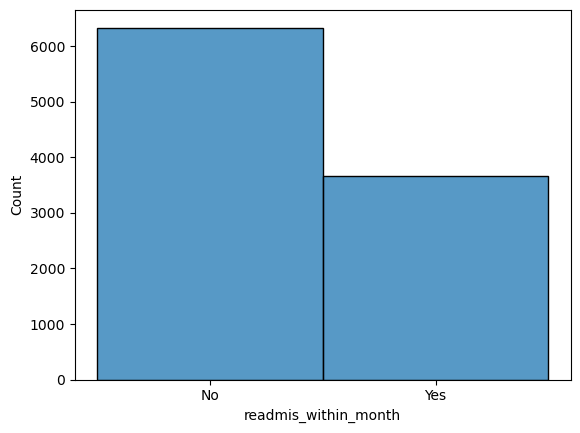

In [38]:
#Code for plotting univariate analysis of readmission
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=df, x="readmis_within_month")

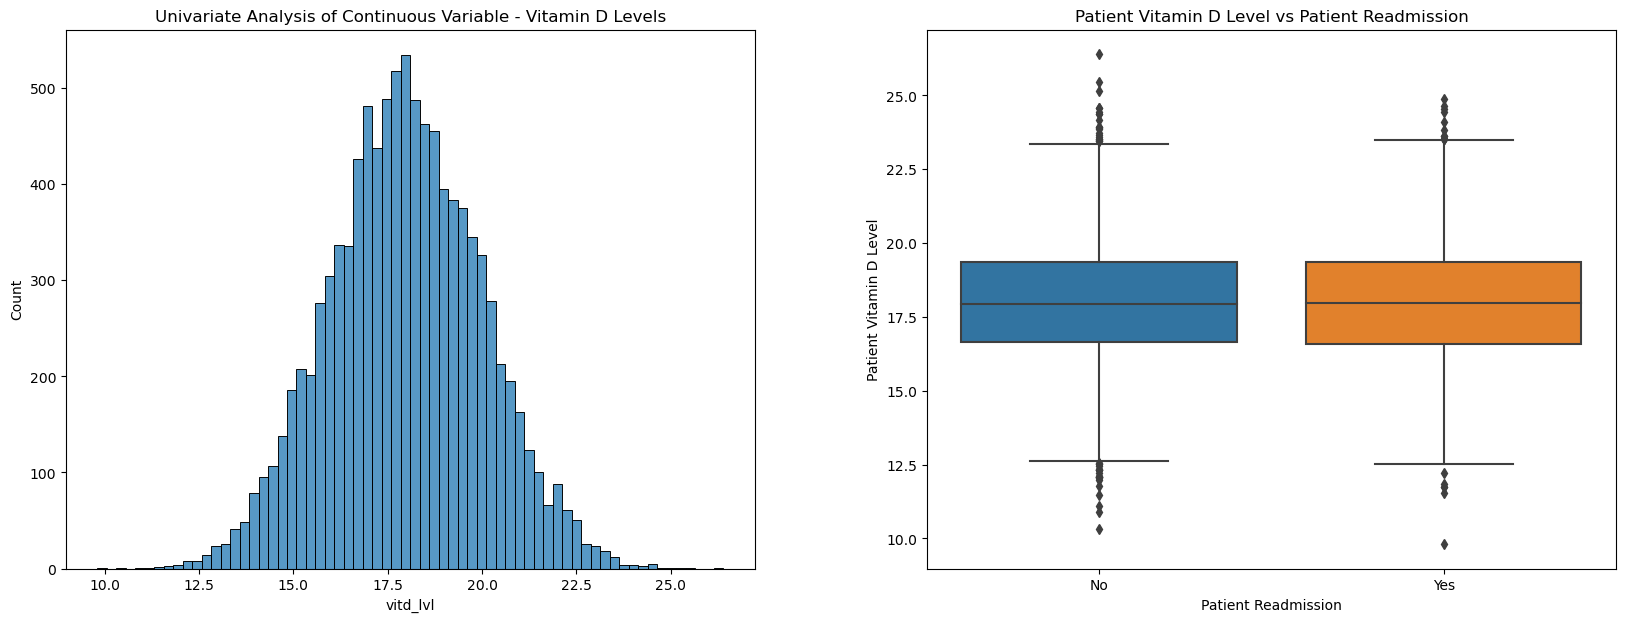

In [40]:
#Code conducting univariate and bivariate analysis exploring the vitamin D level variable and potential relationship with patient readmission
import seaborn as sns
import matplotlib.pyplot as plt
  
#Code for plotting univariate analysis of continuous variables in the form of histograms
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

sns.histplot(data=df, x="vitd_lvl", ax=ax[0])
ax[0].title.set_text("Univariate Analysis of Continuous Variable - Vitamin D Levels")

sns.boxplot(data=df, x='readmis_within_month', y='vitd_lvl', ax=ax[1])
plt.xlabel("Patient Readmission")
plt.ylabel("Patient Vitamin D Level")
ax[1].title.set_text('Patient Vitamin D Level vs Patient Readmission')
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

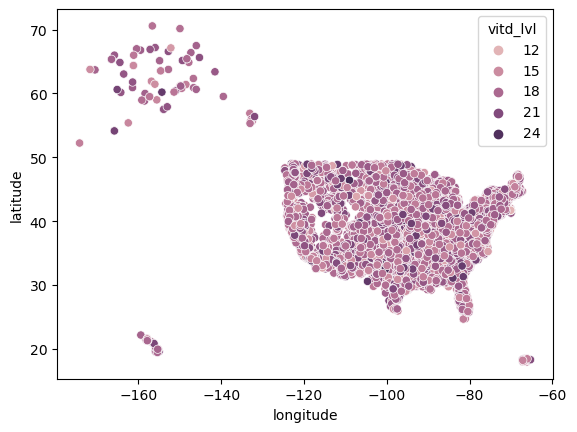

In [42]:
#Checking independence of observations for vitamin D levels by latitude and longitude
sns.scatterplot(data=df, x="longitude", y="latitude", hue="vitd_lvl")

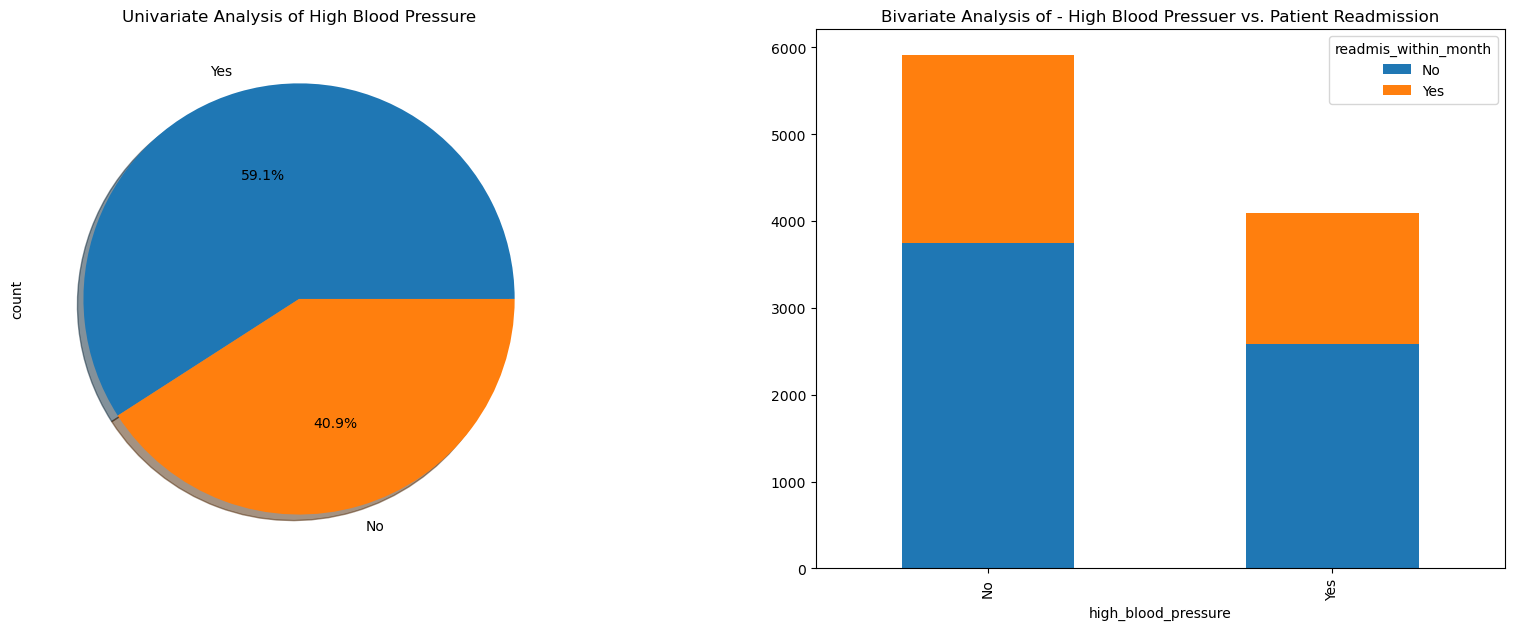

In [43]:
#Code for plotting univariate and bivariate analysis exploring the high blood pressure variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig2, ax=plt.subplots(1,2)
fig2.subplots_adjust(hspace=0.125, wspace=0.25)
fig2.set_size_inches(20,7)

counts = df['high_blood_pressure'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of High Blood Pressure')

ct = pd.crosstab(df['high_blood_pressure'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - High Blood Pressuer vs. Patient Readmission")

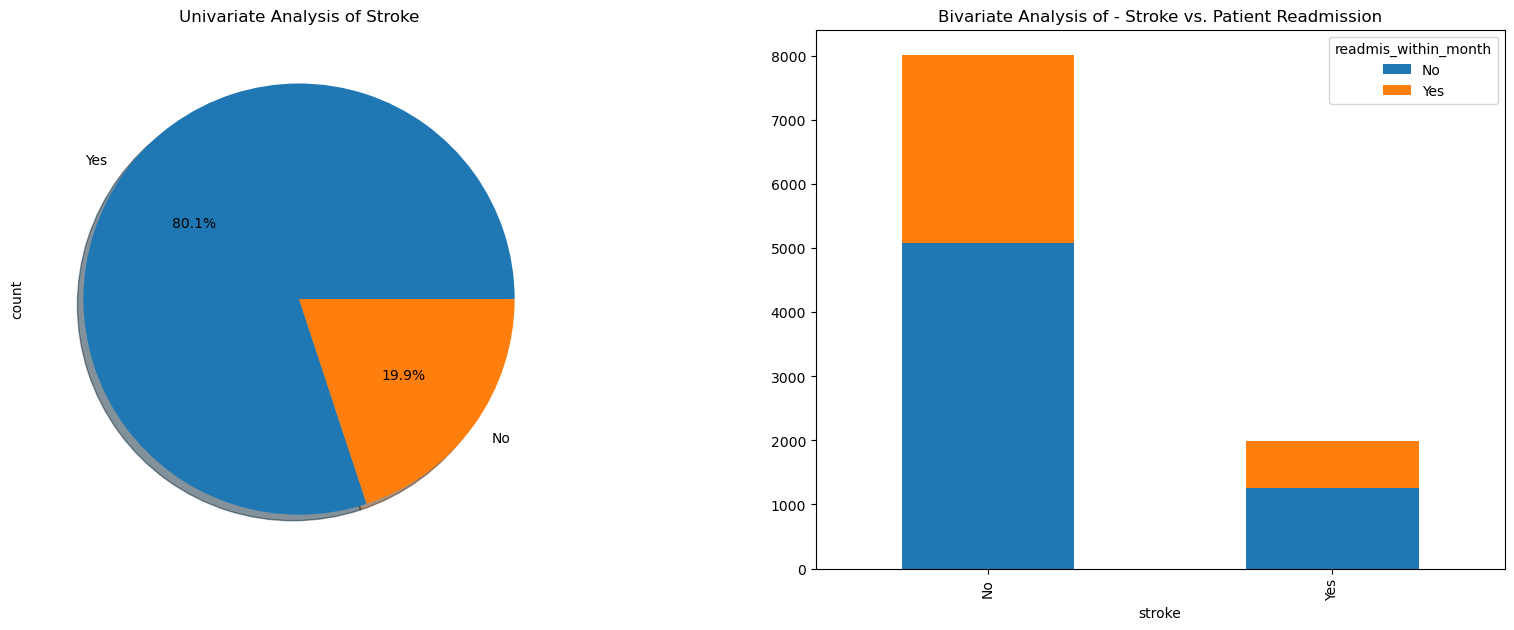

In [44]:
#Code for plotting univariate and bivariate analysis exploring the stroke variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['stroke'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Stroke')

ct = pd.crosstab(df['stroke'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Stroke vs. Patient Readmission")

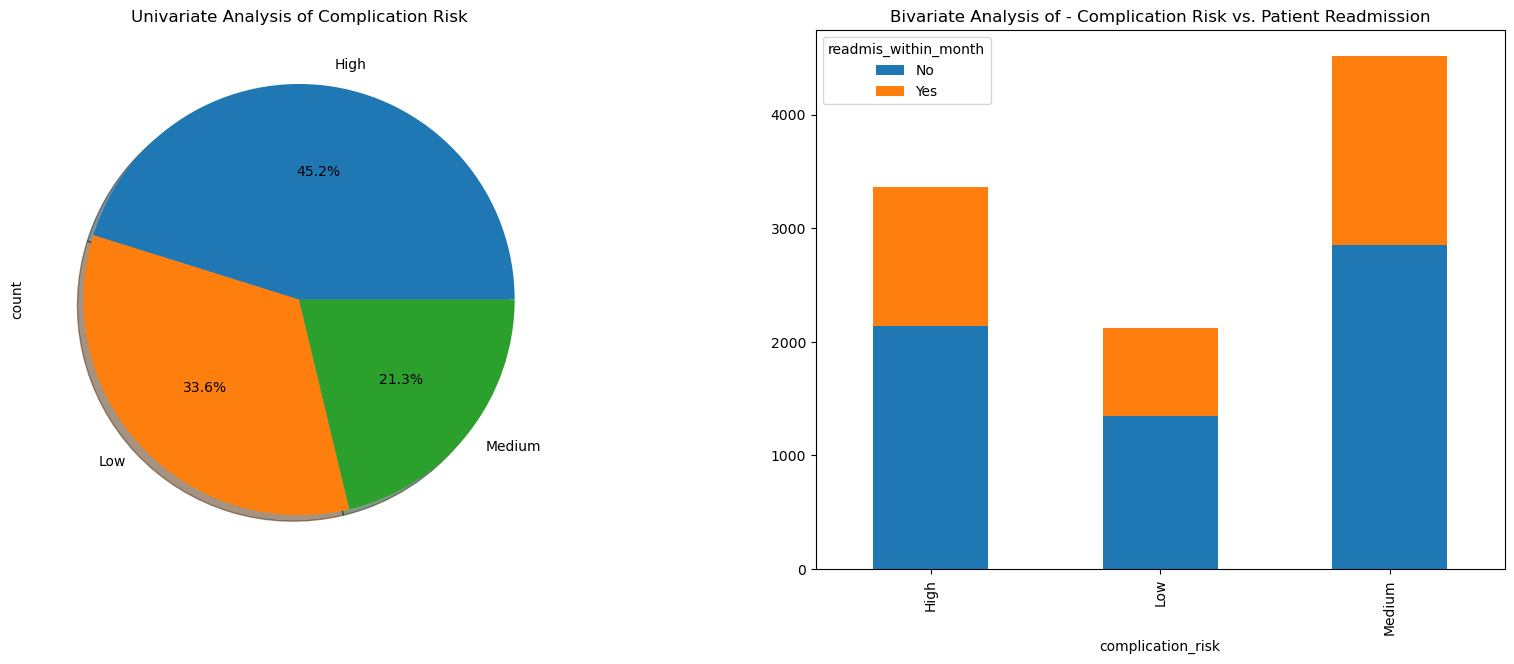

In [45]:
#Code for plotting univariate and bivariate analysis exploring the complication risk variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['complication_risk'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['High', 'Low', 'Medium'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Complication Risk')

ct = pd.crosstab(df['complication_risk'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Complication Risk vs. Patient Readmission")

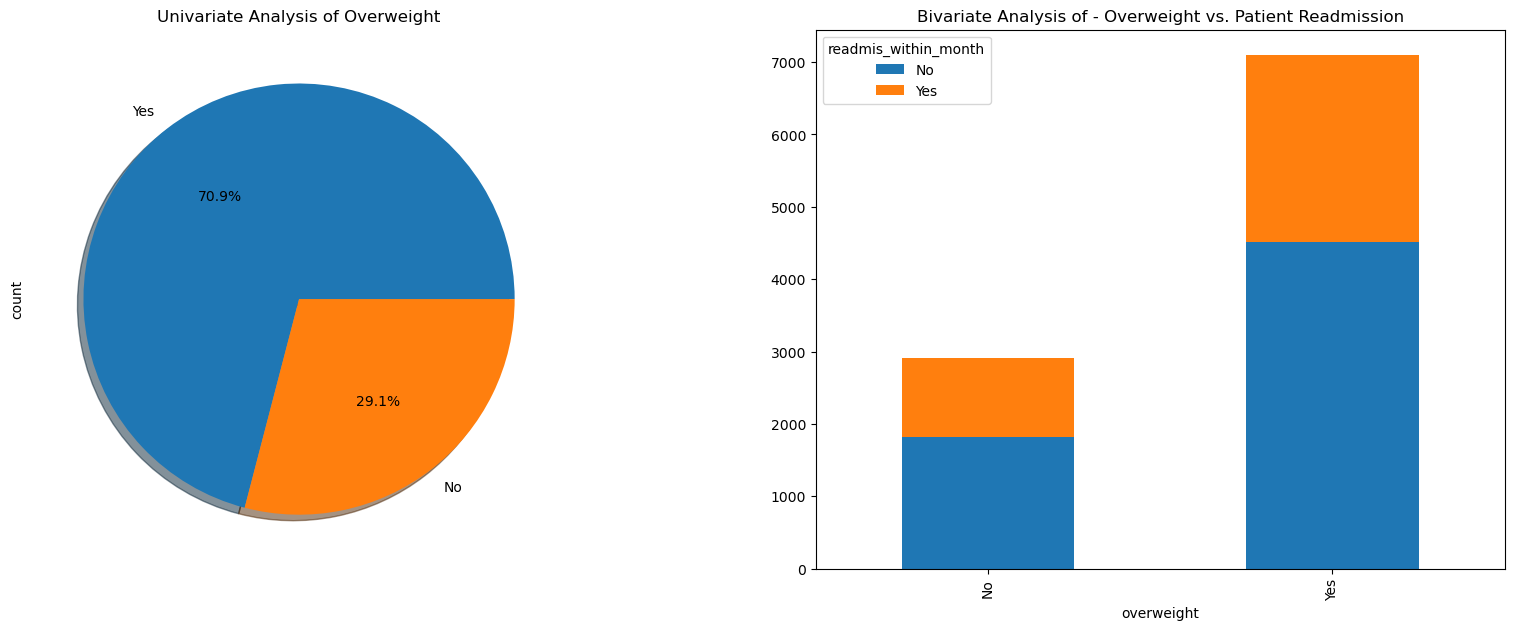

In [46]:
#Code for plotting univariate and bivariate analysis exploring the overweight variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['overweight'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Overweight')

ct = pd.crosstab(df['overweight'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Overweight vs. Patient Readmission")

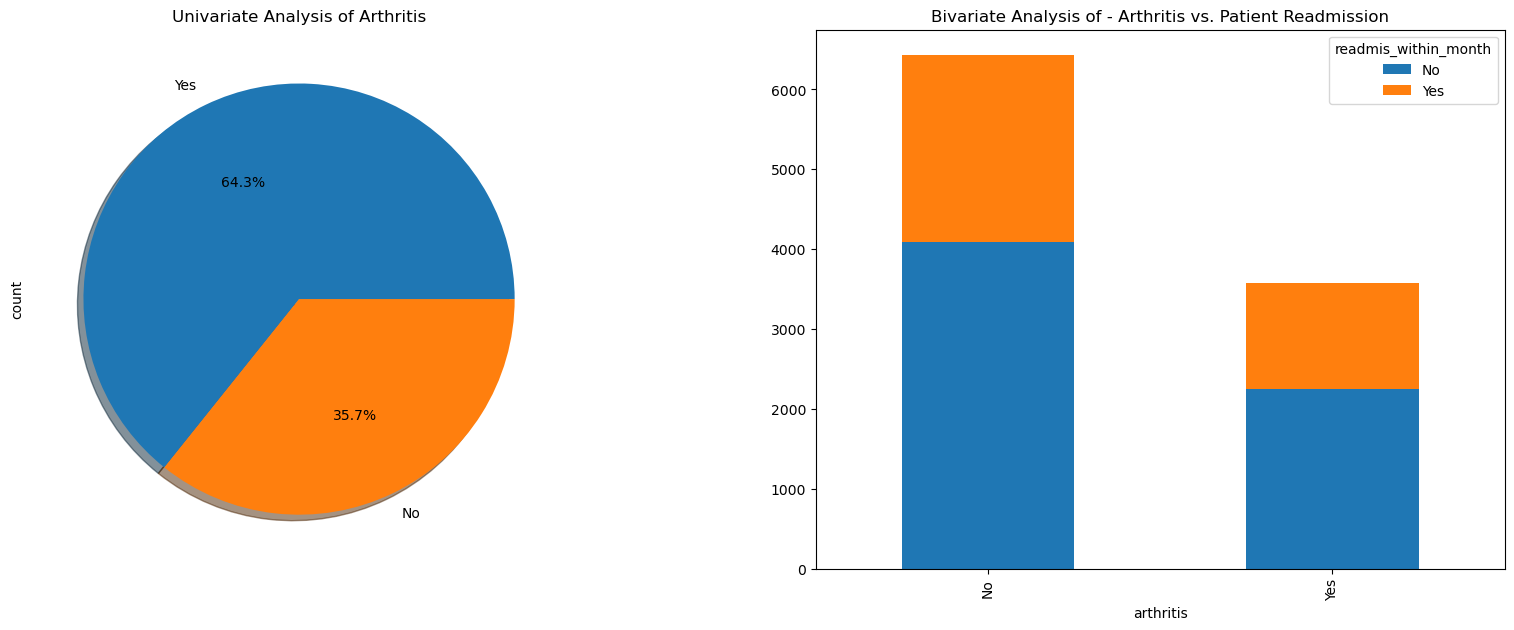

In [47]:
#Code for plotting univariate and bivariate analysis exploring the arthritis variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['arthritis'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Arthritis')

ct = pd.crosstab(df['arthritis'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Arthritis vs. Patient Readmission")

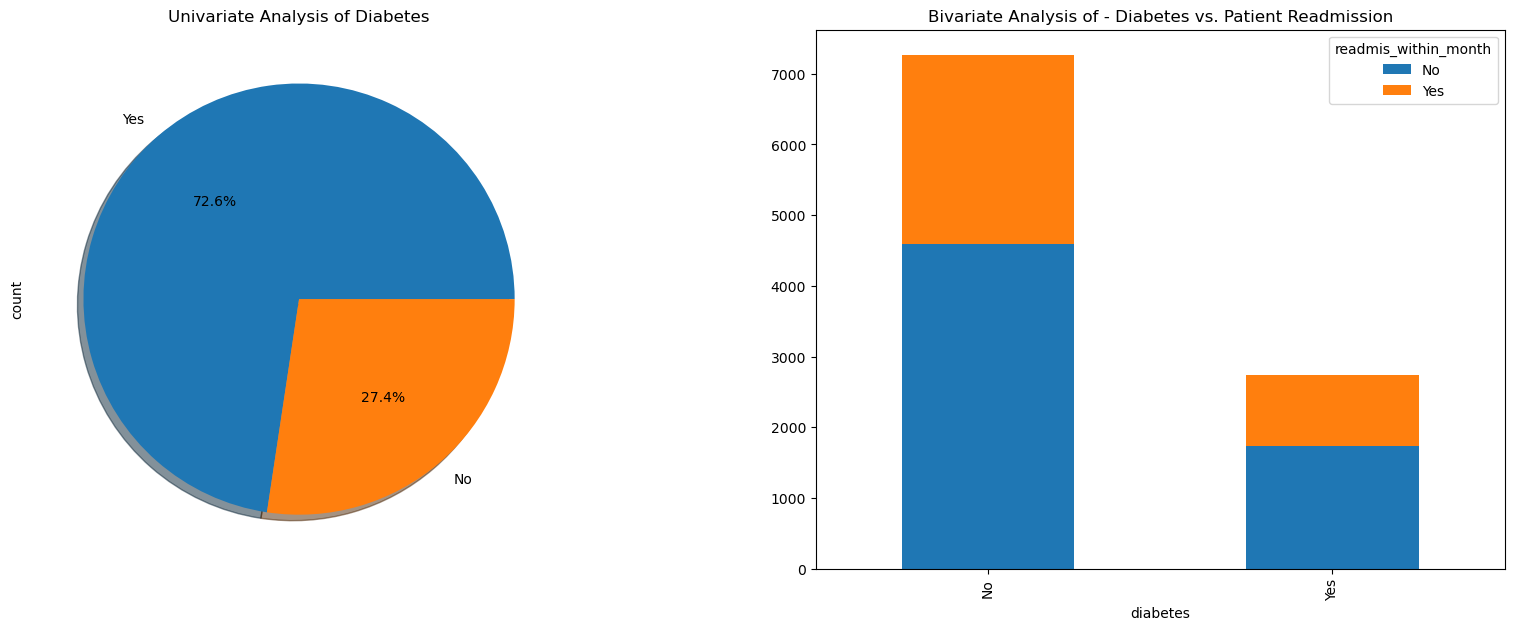

In [48]:
#Code for plotting univariate and bivariate analysis exploring the diabetes variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['diabetes'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Diabetes')

ct = pd.crosstab(df['diabetes'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Diabetes vs. Patient Readmission")

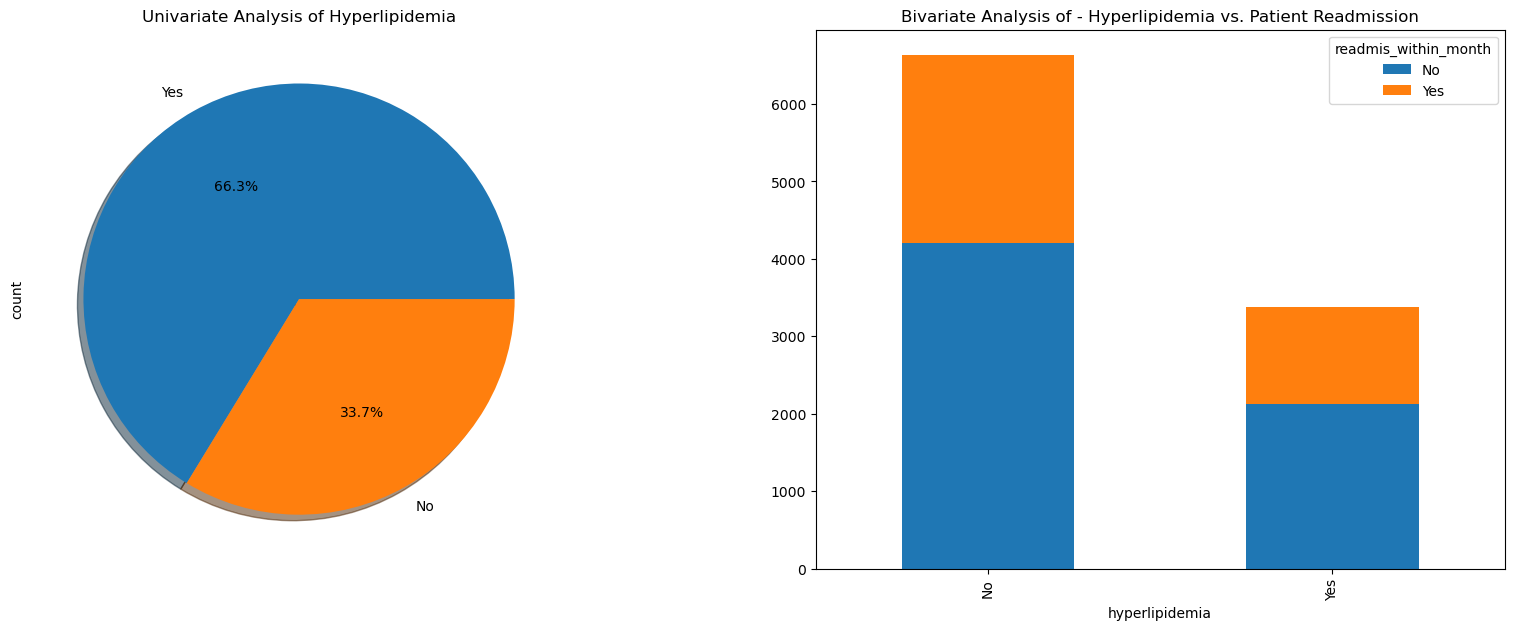

In [49]:
#Code for plotting univariate and bivariate analysis exploring the hyperlipidemia variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['hyperlipidemia'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Hyperlipidemia')

ct = pd.crosstab(df['hyperlipidemia'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Hyperlipidemia vs. Patient Readmission")

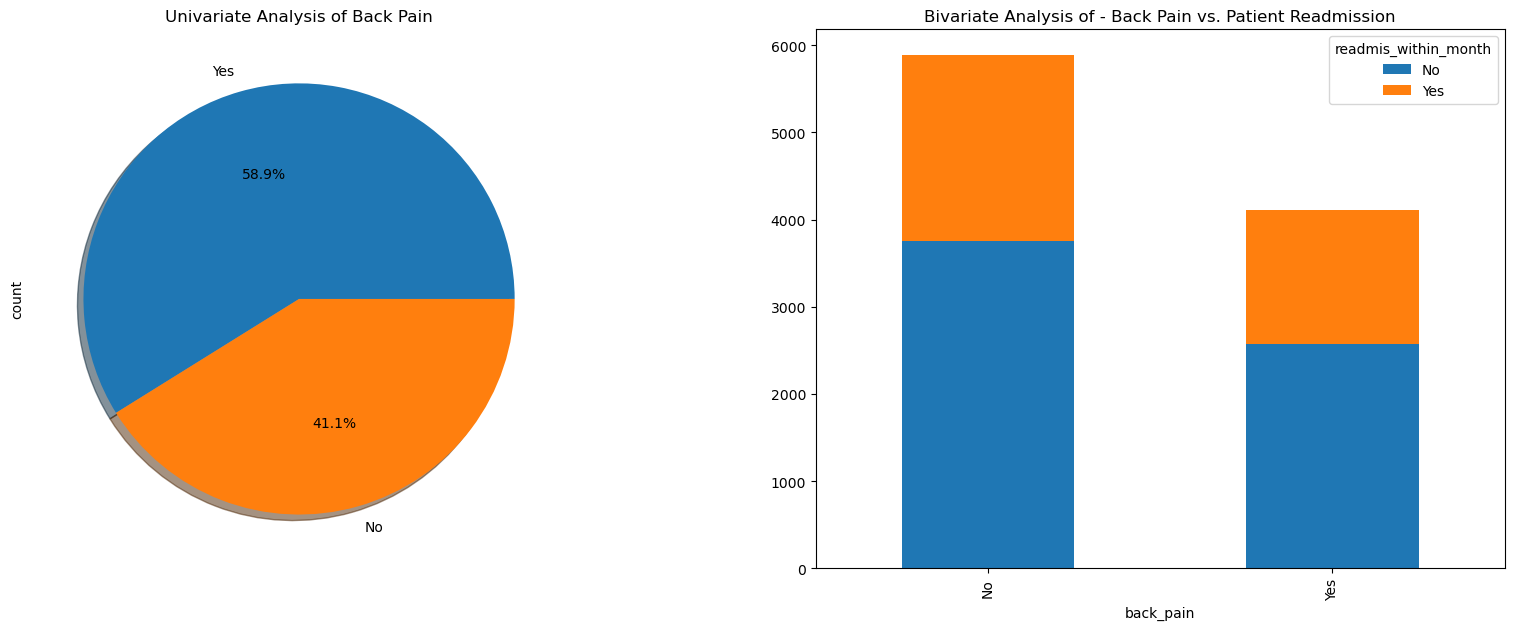

In [50]:
#Code for plotting univariate and bivariate analysis exploring the back pain variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['back_pain'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Back Pain')

ct = pd.crosstab(df['back_pain'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Back Pain vs. Patient Readmission")

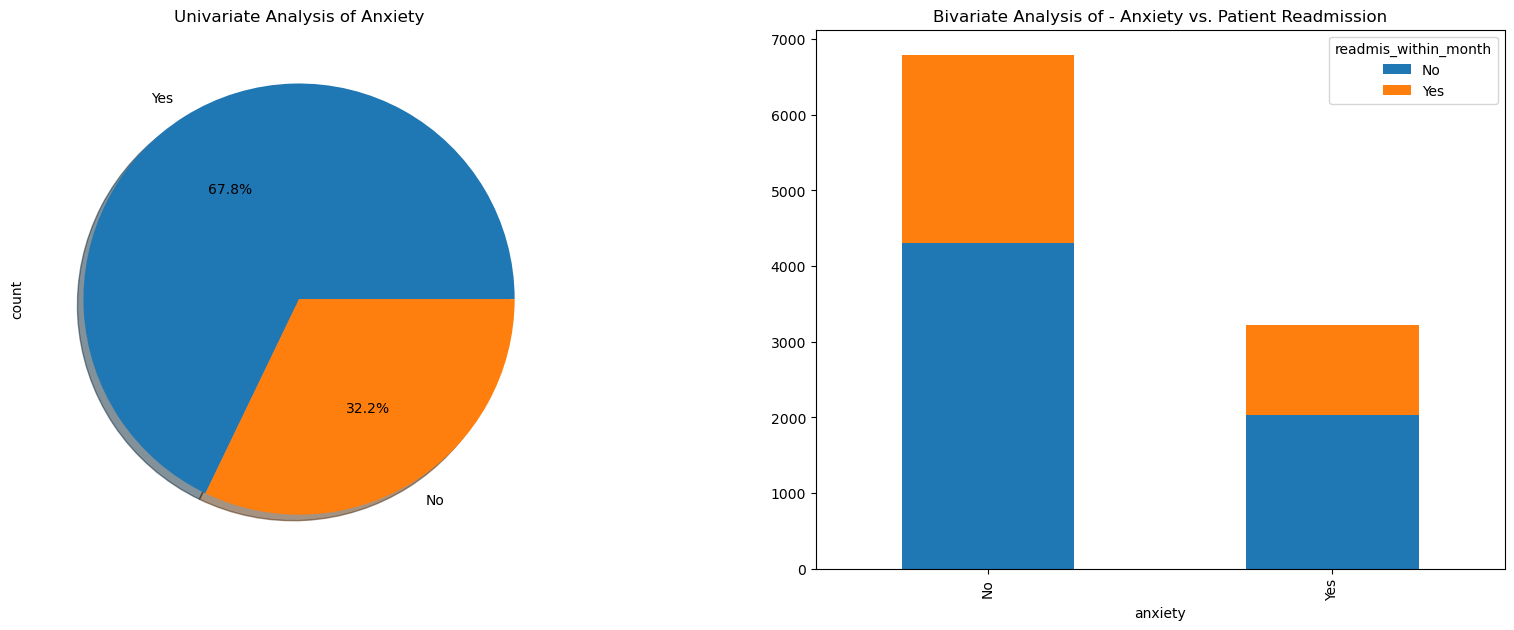

In [51]:
#Code for plotting univariate and bivariate analysis exploring the anxiety variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['anxiety'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Anxiety')

ct = pd.crosstab(df['anxiety'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Anxiety vs. Patient Readmission")

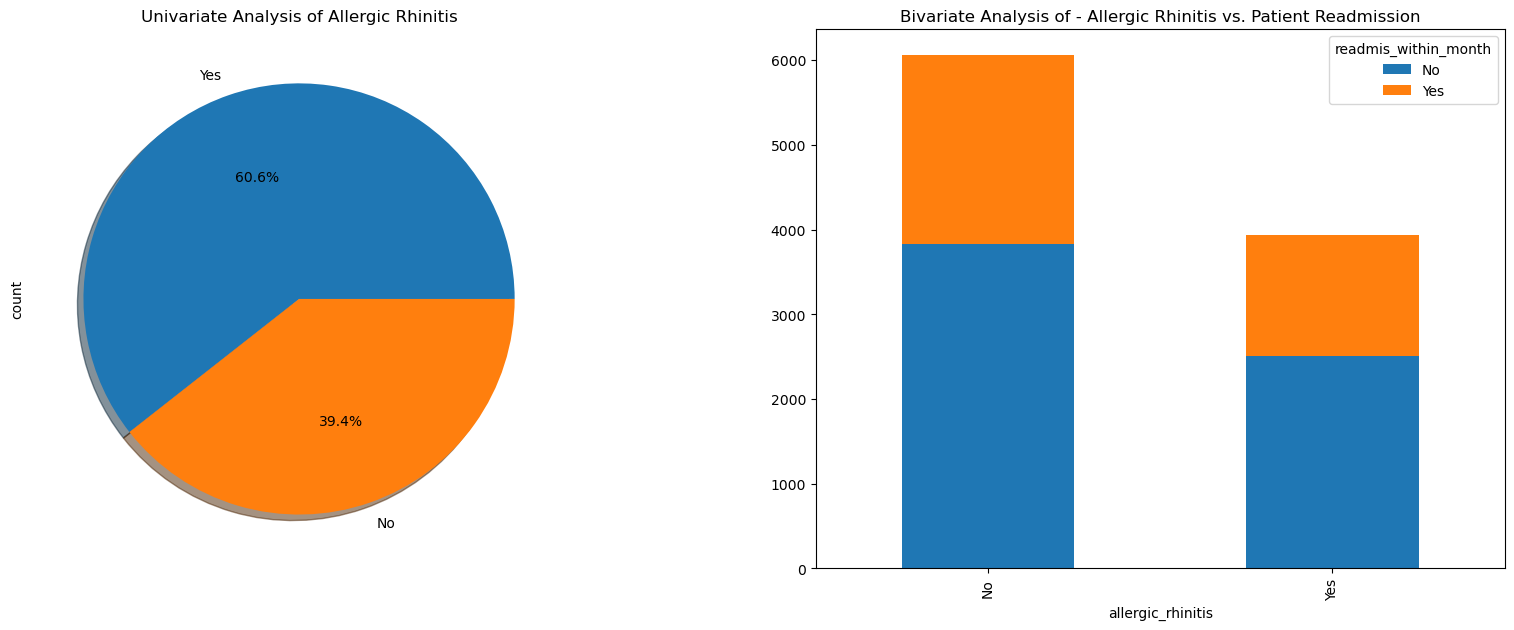

In [52]:
#Code for plotting univariate and bivariate analysis exploring the allergic rhinitis variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['allergic_rhinitis'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Allergic Rhinitis')

ct = pd.crosstab(df['allergic_rhinitis'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Allergic Rhinitis vs. Patient Readmission")

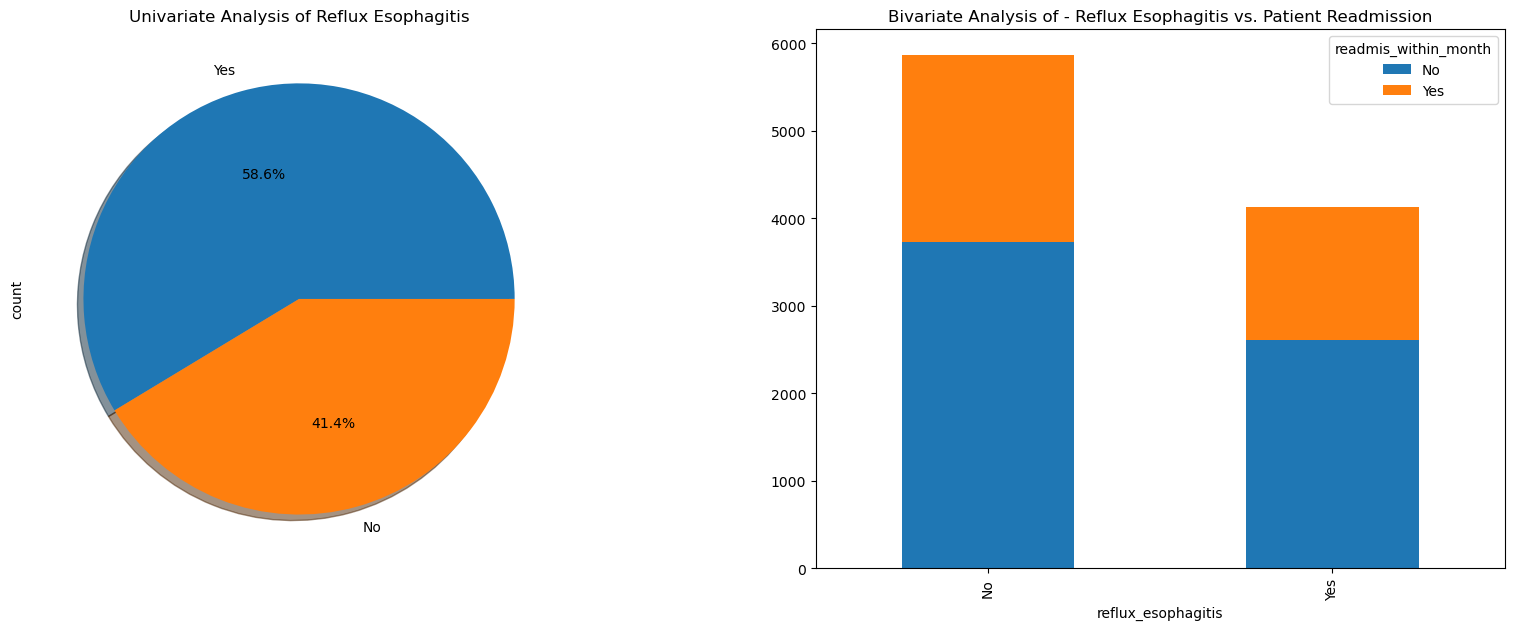

In [53]:
#Code for plotting univariate and bivariate analysis exploring the reflux esophagitis variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['reflux_esophagitis'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Reflux Esophagitis')

ct = pd.crosstab(df['reflux_esophagitis'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Reflux Esophagitis vs. Patient Readmission")

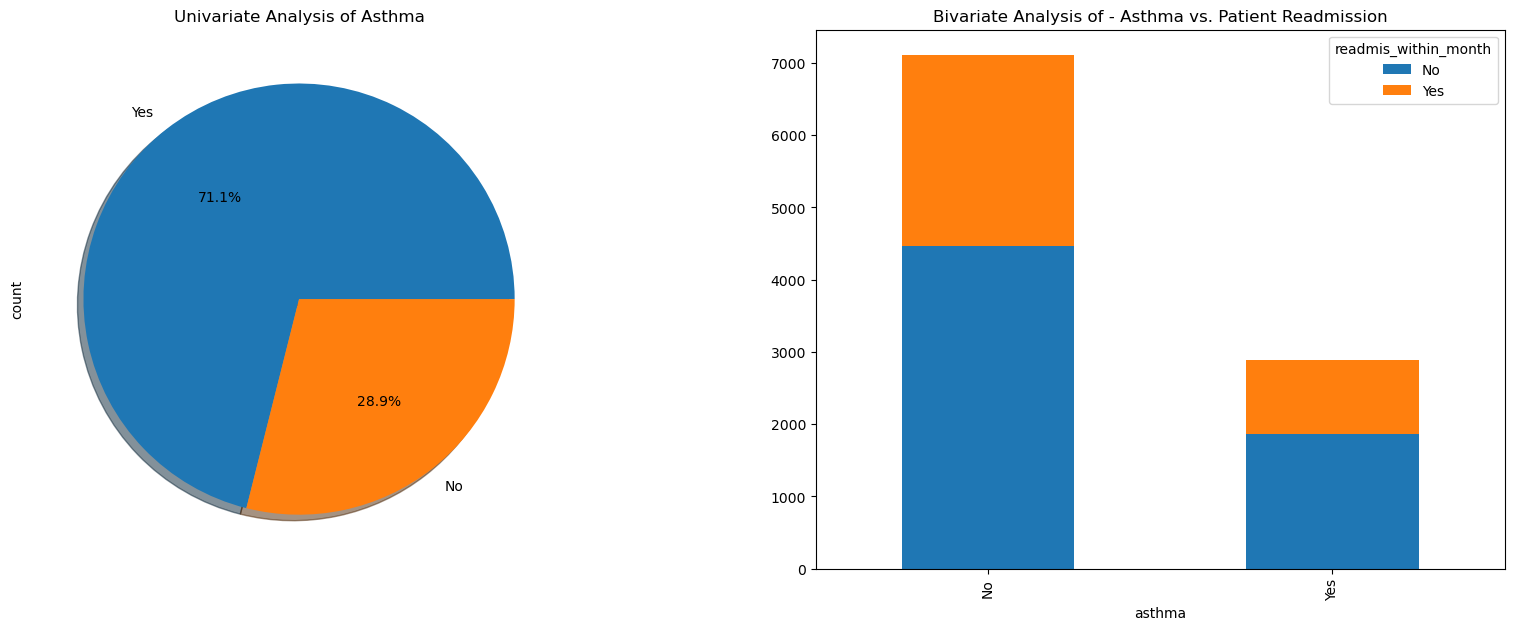

In [54]:
#Code for plotting univariate and bivariate analysis exploring the asthma variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['asthma'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Asthma')

ct = pd.crosstab(df['asthma'], df['readmis_within_month'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of - Asthma vs. Patient Readmission")

In [55]:
#state
df["state"] = df["state"].astype("category")

#zip
df['zip'] = df['zip'].astype("str").str.zfill(5)

#area
df["area"] = df["area"].astype("category")

#timezone
df["timezone"] = df["timezone"].astype("category")

#children_in_household
df["children_in_household"] = df["children_in_household"].astype("Int64")

#marital_status
df["marital_status"] = df["marital_status"].astype("category")

#gender
df["gender"] = df["gender"].astype("category")

#initial_admin
df["initial_admin"] = df["initial_admin"].astype("category")

#complication_risk
df["complication_risk"] = df["complication_risk"].astype("category")

#services
df["services"] = df["services"].astype("category")

#likert_timely_admission
df["likert_timely_admission"] = df["likert_timely_admission"].astype("category")

#likert_timely_treatment
df["likert_timely_treatment"] = df["likert_timely_treatment"].astype("category")

#likert_timely_visit
df["likert_timely_visit"] = df["likert_timely_visit"].astype("category")

#likert_reliablity
df["likert_reliablity"] = df["likert_reliablity"].astype("category")

#likert_options
df["likert_options"] = df["likert_options"].astype("category")

#likert_treatment_hrs
df["likert_treatment_hrs"] = df["likert_treatment_hrs"].astype("category")

#likert_courteous_staff
df["likert_courteous_staff"] = df["likert_courteous_staff"].astype("category")

#likert_dr_active_listening
df["likert_dr_active_listening"] = df["likert_dr_active_listening"].astype("category")

#Code converting the "complication_risk" variable into two new binary variables using dummy coding
comp_risk = pd.get_dummies(data=df["complication_risk"], drop_first=True, dtype=int)
#One-hot encoding converting categorical variables into numerical format by generating a new binary column for each category
df['readmis_within_month'] = df['readmis_within_month'].map({'Yes': 1, 'No': 0})
df['high_blood_pressure'] = df['high_blood_pressure'].map({'Yes': 1, 'No': 0})
df['stroke'] = df['stroke'].map({'Yes': 1, 'No': 0})
df['overweight'] = df['overweight'].map({'Yes': 1, 'No': 0})
df['arthritis'] = df['arthritis'].map({'Yes': 1, 'No': 0})
df['diabetes'] = df['diabetes'].map({'Yes': 1, 'No': 0})
df['hyperlipidemia'] = df['hyperlipidemia'].map({'Yes': 1, 'No': 0})
df['back_pain'] = df['back_pain'].map({'Yes': 1, 'No': 0})
df['anxiety'] = df['anxiety'].map({'Yes': 1, 'No': 0})
df['allergic_rhinitis'] = df['allergic_rhinitis'].map({'Yes': 1, 'No': 0})
df['reflux_esophagitis'] = df['reflux_esophagitis'].map({'Yes': 1, 'No': 0})
df['asthma'] = df['asthma'].map({'Yes': 1, 'No': 0})
#Code to reduce dataset to only include the variables we care about for the multiple regression model
logistic_df = df[["vitd_lvl", "high_blood_pressure", "stroke", "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain", "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma", "readmis_within_month"]]
# Dummies for Complication Risk
logistic_df.insert(4, "comp_risk_medium", comp_risk.Medium)
logistic_df.insert(4, "comp_risk_low", comp_risk.Low)
logistic_df

,vitd_lvl,high_blood_pressure,stroke,overweight,comp_risk_low,comp_risk_medium,arthritis,diabetes,hyperlipidemia,back_pain,anxiety,allergic_rhinitis,reflux_esophagitis,asthma,readmis_within_month
CaseOrder,,,,,,,,,,,,,,,
1,19.141466,1,0,0,0,1,1,1,0,1,1,1,0,1,0
2,18.940352,1,0,1,0,0,0,0,0,0,0,0,1,0,0
3,18.057507,1,0,1,0,1,0,1,0,0,0,0,0,0,0
4,16.576858,0,1,0,0,1,1,0,0,0,0,0,1,1,0
5,17.439069,0,0,0,1,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,16.980860,1,0,0,0,1,0,0,0,0,1,0,1,0,0
9997,18.177020,1,0,1,0,1,1,1,0,0,0,0,0,1,1
9998,17.129070,1,0,1,0,0,0,0,0,0,1,1,0,0,1


In [56]:
# Save dataset to CSV, ignore index (if included, this will create an additional unnecessary column)
logistic_df.to_csv('prepared.csv', index=False)
logistic_df.info(memory_usage="deep")
logistic_df.to_csv(r'C:\Users\My Name Devon\OneDrive\Documents\WGU MSDA\D208\Task 2\prepared_data_set')

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vitd_lvl              10000 non-null  float64
 1   high_blood_pressure   10000 non-null  int64  
 2   stroke                10000 non-null  int64  
 3   overweight            10000 non-null  int64  
 4   comp_risk_low         10000 non-null  int32  
 5   comp_risk_medium      10000 non-null  int32  
 6   arthritis             10000 non-null  int64  
 7   diabetes              10000 non-null  int64  
 8   hyperlipidemia        10000 non-null  int64  
 9   back_pain             10000 non-null  int64  
 10  anxiety               10000 non-null  int64  
 11  allergic_rhinitis     10000 non-null  int64  
 12  reflux_esophagitis    10000 non-null  int64  
 13  asthma                10000 non-null  int64  
 14  readmis_within_month  10000 non-null  int64  
dtypes: float64(1), int32(2),

In [57]:
import statsmodels.api as sm
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "high_blood_pressure", "stroke", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)
logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656920
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9985
Method:                             MLE   Df Model:                           14
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005557
Time:                          22:23:08   Log-Likelihood:                -6569.2
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.9223
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
vitd_lvl                0.0045      0.010      0.435      0.664      -0.01

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x = logistic_df[["vitd_lvl", "high_blood_pressure", "stroke", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns

vif_df["VIF"] = [variance_inflation_factor(x.values, i)
for i in range(len(x.columns))]

print(vif_df)

                feature        VIF
0              vitd_lvl   1.001496
1   high_blood_pressure   1.001969
2                stroke   1.000942
3         comp_risk_low   1.287402
4      comp_risk_medium   1.287350
5            overweight   1.001813
6             arthritis   1.001871
7              diabetes   1.001636
8        hyperlipidemia   1.001136
9             back_pain   1.001716
10              anxiety   1.001106
11    allergic_rhinitis   1.000847
12   reflux_esophagitis   1.001080
13               asthma   1.001141
14                const  90.231187


In [60]:
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

#Remove stroke with a p-value of 0.913
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

scaler = MinMaxScaler()
continuous_cols = ['vitd_lvl']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656921
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9986
Method:                             MLE   Df Model:                           13
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005548
Time:                          22:25:02   Log-Likelihood:                -6569.2
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.8864
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
vitd_lvl                0.0744      0.171      0.435      0.663      -0.26

In [61]:
#Remove anxiety with a p-value of 0.816
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

scaler = MinMaxScaler()
continuous_cols = ['vitd_lvl']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])


logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656923
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9987
Method:                             MLE   Df Model:                           12
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005507
Time:                          22:25:08   Log-Likelihood:                -6569.2
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.8414
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
vitd_lvl                0.0747      0.171      0.437      0.662      -0.26

In [62]:
#Remove high_blood_pressure with a p-value of 0.797
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

scaler = MinMaxScaler()
continuous_cols = ['vitd_lvl']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])


logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656927
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9988
Method:                             MLE   Df Model:                           11
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005456
Time:                          22:25:14   Log-Likelihood:                -6569.3
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.7849
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
vitd_lvl               0.0749      0.171      0.439      0.661      -0.260  

In [64]:
#Remove diabetes with a p-value of 0.794
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "hyperlipidemia", "back_pain",
       "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

scaler = MinMaxScaler()
continuous_cols = ['vitd_lvl']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656930
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9989
Method:                             MLE   Df Model:                           10
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005404
Time:                          22:25:34   Log-Likelihood:                -6569.3
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.7155
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
vitd_lvl               0.0760      0.171      0.445      0.656      -0.259  

In [65]:
#Remove comp_risk_low with a p-value of 0.787 and comp_risk_med with a p-value of 0.700 simultaneously
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "overweight", "arthritis", "hyperlipidemia", "back_pain",
       "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

scaler = MinMaxScaler()
continuous_cols = ['vitd_lvl']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])


logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656938
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9991
Method:                             MLE   Df Model:                            8
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005284
Time:                          22:26:00   Log-Likelihood:                -6569.4
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.5425
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
vitd_lvl               0.0763      0.171      0.447      0.655      -0.258  

In [67]:
#Remove hyperlipidemia with a p-value of 0.676
y = logistic_df.readmis_within_month
X = logistic_df[["vitd_lvl", "overweight", "arthritis", "back_pain",
       "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

scaler = MinMaxScaler()
continuous_cols = ['vitd_lvl']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656947
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9992
Method:                             MLE   Df Model:                            7
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005151
Time:                          22:26:07   Log-Likelihood:                -6569.5
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.4531
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
vitd_lvl               0.0754      0.171      0.442      0.658      -0.259  

In [68]:
#Remove vitd_lvl with a p-value of 0.658
y = logistic_df.readmis_within_month
X = logistic_df[["overweight", "arthritis", "back_pain",
       "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656956
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9993
Method:                             MLE   Df Model:                            6
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0005003
Time:                          22:26:12   Log-Likelihood:                -6569.6
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.3618
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
overweight            -0.0385      0.046     -0.844      0.399      -0.128  

In [69]:
#Remove allergic_rhinitis with a p-value of 0.643
y = logistic_df.readmis_within_month
X = logistic_df[["overweight", "arthritis", "back_pain",
       "reflux_esophagitis", "asthma"]].assign(const=1)
logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656967
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9994
Method:                             MLE   Df Model:                            5
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0004839
Time:                          22:26:16   Log-Likelihood:                -6569.7
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.2727
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
overweight            -0.0386      0.046     -0.845      0.398      -0.128  

In [70]:
#Remove arthritis with a p-value of 0.620
y = logistic_df.readmis_within_month
X = logistic_df[["overweight", "back_pain", "reflux_esophagitis", "asthma"]].assign(const=1)
logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656997
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9995
Method:                             MLE   Df Model:                            4
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0004380
Time:                          22:26:20   Log-Likelihood:                -6570.0
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.2180
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
overweight            -0.0384      0.046     -0.842      0.400      -0.128  

In [71]:
#Remove reflux_esophagitis with a p-value of 0.612
y = logistic_df.readmis_within_month
X = logistic_df[["overweight", "back_pain","asthma"]].assign(const=1)
logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.657010
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9996
Method:                             MLE   Df Model:                            3
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0004184
Time:                          22:26:26   Log-Likelihood:                -6570.1
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                    0.1386
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
overweight    -0.0387      0.046     -0.848      0.396      -0.128       0.051
back_pain    

In [72]:
#Remove overweight with a p-value of 0.396
y = logistic_df.readmis_within_month
X = logistic_df[["back_pain","asthma"]].assign(const=1)
logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.657046
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9997
Method:                             MLE   Df Model:                            2
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0003637
Time:                          22:26:30   Log-Likelihood:                -6570.5
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                   0.09155
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
back_pain      0.0571      0.042      1.356      0.175      -0.025       0.140
asthma       

In [73]:
#Remove back_pain with a p-value of 0.175
y = logistic_df.readmis_within_month
X = logistic_df[["asthma"]].assign(const=1)
logistic_model=sm.Logit(y,X)
result=logistic_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.657138
         Iterations 4
                            Logit Regression Results                            
Dep. Variable:     readmis_within_month   No. Observations:                10000
Model:                            Logit   Df Residuals:                     9998
Method:                             MLE   Df Model:                            1
Date:                  Sun, 30 Mar 2025   Pseudo R-squ.:               0.0002240
Time:                          22:26:35   Log-Likelihood:                -6571.4
converged:                         True   LL-Null:                       -6572.9
Covariance Type:              nonrobust   LLR p-value:                   0.08618
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
asthma        -0.0788      0.046     -1.713      0.087      -0.169       0.011
const        

In [74]:
# Split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

# Import the class
from sklearn.linear_model import LogisticRegression

# Instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# Fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1575,    0],
       [ 925,    0]], dtype=int64)

Text(0.5, 427.9555555555555, 'Predicted label')

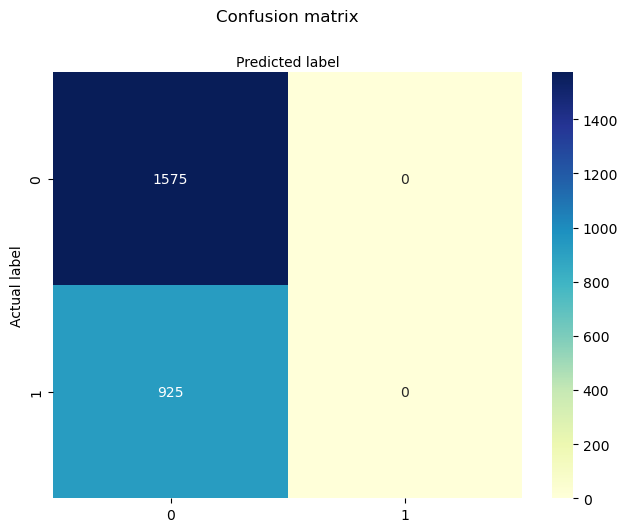

In [75]:
# Import required modules
import matplotlib.pyplot as plt

# Name  of classes
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [76]:
# Print accuracy of model
print((metrics.accuracy_score(y_test, y_pred)*100),'%')

63.0 %


In [78]:
#Interpretting coefficients

print(f"The odds ratio for asthma is {round(np.exp(-0.0788), 2)}. Given this, the change in odds for patient readmission is {round((np.exp(-0.0788) - 1) * 100, 2)}%")

The odds ratio for asthma is 0.92. Given this, the change in odds for patient readmission is -7.58%
